In [1]:
!pip install osmnx geopandas networkx contextily folium shapely pyproj

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 4.6 MB/s eta 0:00:00


In [2]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

print("OSMnx Version:", ox.__version__)

OSMnx Version: 2.1.0


In [3]:
place = "Chengannur, Kerala, India"

area = ox.geocode_to_gdf(place)



G = ox.graph_from_polygon(
    area.geometry.iloc[0],
    network_type="drive",
    simplify=True
)

print(f"Nodes : {len(G.nodes)}")
print(f"Edges : {len(G.edges)}")

Nodes : 3457
Edges : 8571


In [ ]:
nodes, edges = ox.graph_to_gdfs(G)

display(nodes.head())

display(edges.head())

print(nodes.shape)

print(edges.shape)

In [ ]:
fig, ax = ox.plot_graph(
    G,
    node_size=0,
    edge_linewidth=0.5,
    edge_color="gray",
    bgcolor="white",
    show=False,
    close=False
)

plt.title("Road Network of Chengannur")

plt.show()

In [6]:
def extract_features(tag_key, tag_value):

    features = ox.features_from_place(
        place,
        {tag_key: tag_value}
    )

    if features.empty:
        return None

    features = features.copy()

    features["geometry"] = features.geometry.representative_point()

    features["nearest_node"] = ox.distance.nearest_nodes(
        G,
        X=features.geometry.x,
        Y=features.geometry.y
    )

    return features

In [7]:
tags = {
    "amenity": [
        "hospital",
        "school",
        "police",
        "fire_station",
        "bus_station"
    ]
}

all_features = ox.features_from_place(place, tags)

In [8]:
infrastructure = {}

for amenity in [
    "hospital",
    "school",
    "police",
    "fire_station",
    "bus_station"
]:

    df = all_features[
        all_features["amenity"] == amenity
    ].copy()

    if not df.empty:

        df["geometry"] = df.geometry.representative_point()

        df["nearest_node"] = ox.distance.nearest_nodes(
            G,
            X=df.geometry.x,
            Y=df.geometry.y
        )

    infrastructure[amenity] = df

In [9]:
for key,value in infrastructure.items():

    if value is None:

        print(f"{key} : 0")

    else:

        print(f"{key} : {len(value)}")

hospital : 43
school : 113
police : 6
fire_station : 1
bus_station : 4


In [10]:
bridge_edges = edges[
    edges["bridge"].notna()
].copy()

bridge_edges["geometry"] = bridge_edges.geometry.representative_point()

bridge_edges["nearest_node"] = ox.distance.nearest_nodes(
    G,
    X=bridge_edges.geometry.x,
    Y=bridge_edges.geometry.y
)

print(f"Bridges : {len(bridge_edges)}")

Bridges : 324


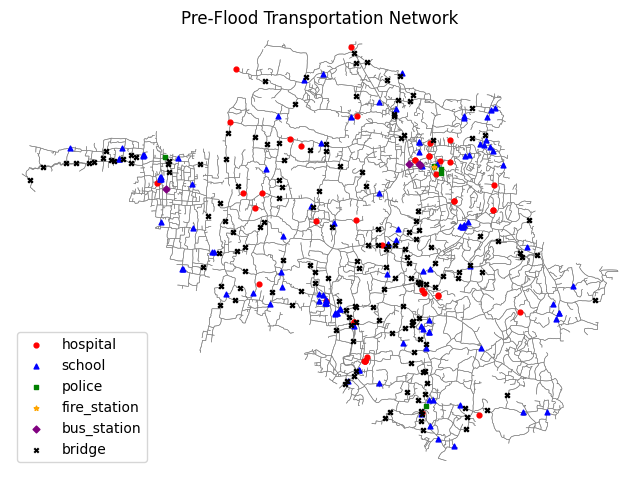

In [11]:
fig, ax = ox.plot_graph(
    G,
    node_size=0,
    edge_linewidth=0.4,
    edge_color="gray",
    bgcolor="white",
    show=False,
    close=False
)

colors = {
    "hospital":"red",
    "school":"blue",
    "police":"green",
    "fire_station":"orange",
    "bus_station":"purple"
}

markers = {
    "hospital":"o",
    "school":"^",
    "police":"s",
    "fire_station":"*",
    "bus_station":"D"
}

for feature,data in infrastructure.items():

    if data is not None:

        data.plot(
            ax=ax,
            color=colors[feature],
            marker=markers[feature],
            markersize=12,
            label=feature
        )

bridge_edges.plot(
    ax=ax,
    color="black",
    marker="x",
    markersize=10,
    label="bridge"
)

plt.legend()

plt.title("Pre-Flood Transportation Network")

plt.show()

In [12]:
bridge_edges[["bridge", "name", "length"]].head(30)
bridge_edges["bridge"].value_counts()

,count
bridge,
yes,324


In [13]:
print("=" * 50)
print("ROAD NETWORK")
print("=" * 50)

print(f"Nodes                : {G.number_of_nodes()}")
print(f"Edges                : {G.number_of_edges()}")
print(f"Graph Type           : {type(G).__name__}")
print(f"Is Directed          : {nx.is_directed(G)}")

ROAD NETWORK
Nodes                : 3457
Edges                : 8571
Graph Type           : MultiDiGraph
Is Directed          : True


In [14]:

undirected_graph = G.to_undirected()

components = list(nx.connected_components(undirected_graph))

print(f"Connected Components : {len(components)}")

largest_component = max(components, key=len)

print(f"Largest Component    : {len(largest_component)} nodes")

print(f"Nodes Outside Largest Component : {G.number_of_nodes()-len(largest_component)}")

Connected Components : 1
Largest Component    : 3457 nodes
Nodes Outside Largest Component : 0


In [15]:
highway_types = (
    edges["highway"]
    .explode()
    .value_counts(dropna=False)
)

display(highway_types)

,count
highway,
residential,4208
secondary,1808
unclassified,1470
tertiary,453
primary,303
trunk,238
living_street,136
road,4
trunk_link,4


In [16]:
degree = dict(G.degree())

dead_ends = [node for node, deg in degree.items() if deg == 1]

print(f"Dead-End Nodes : {len(dead_ends)}")

Dead-End Nodes : 2


In [17]:
for feature, data in infrastructure.items():

    if data is None:
        continue

    duplicates = data["nearest_node"].duplicated().sum()

    print(f"{feature:<15} : {duplicates} duplicate graph nodes")

hospital        : 7 duplicate graph nodes
school          : 20 duplicate graph nodes
police          : 1 duplicate graph nodes
fire_station    : 0 duplicate graph nodes
bus_station     : 0 duplicate graph nodes


In [18]:
for feature, data in infrastructure.items():

    if data is None:
        continue



    print(feature.upper())



    duplicate_names = data["name"].value_counts()

    duplicate_names = duplicate_names[duplicate_names > 1]

    if len(duplicate_names) == 0:

        print("No duplicate names.")

    else:

        display(duplicate_names)

HOSPITAL
No duplicate names.
SCHOOL


,count
name,
DBHSS CHERIYANAD OLD BUILDING,2
MMAR SCHOOL,2
Thripparavoor English Medium School,2
SREE VIJAYESWARI HIGH SCHOOL,2


POLICE
No duplicate names.
FIRE_STATION
No duplicate names.
BUS_STATION


,count
name,
Chengannur KSRTC Bus Stand,2


In [19]:
print(edges["length"].describe())

count    8571.000000
mean      189.462897
std       174.037942
min         0.720347
25%        73.403111
50%       138.040894
75%       248.830690
max      1750.862415
Name: length, dtype: float64


In [20]:
print(f"Bridge Segments : {len(bridge_edges)}")

print("\nBridge Length Statistics\n")

print(bridge_edges["length"].describe())

Bridge Segments : 324

Bridge Length Statistics

count     324.000000
mean      344.821139
std       280.455553
min         8.263103
25%       123.589681
50%       275.296016
75%       517.116111
max      1306.272135
Name: length, dtype: float64


In [21]:
for feature, data in infrastructure.items():

    if data is None:
        continue

    print("\n"+feature)

    display(data[["name"]].isna().sum())


hospital


,0
name,1



school


,0
name,18



police


,0
name,0



fire_station


,0
name,0



bus_station


,0
name,0


In [22]:
print("VALIDATION REPORT")

print(f"Road Nodes           : {len(nodes)}")
print(f"Road Edges           : {len(edges)}")
print(f"Bridge Segments      : {len(bridge_edges)}")

for feature,data in infrastructure.items():

    if data is None:

        print(f"{feature:<20}: 0")

    else:

        print(f"{feature:<20}: {len(data)}")



VALIDATION REPORT
Road Nodes           : 3457
Road Edges           : 8571
Bridge Segments      : 324
hospital            : 43
school              : 113
police              : 6
fire_station        : 1
bus_station         : 4


In [23]:
waterways = ox.features_from_place(
    place,
    {"waterway": True}
)

print(f"Total Waterways : {len(waterways)}")

rivers = waterways[waterways["waterway"] == "river"].copy()

print(f"River Features : {len(rivers)}")

Total Waterways : 589
River Features : 24


In [ ]:
fig, ax = ox.plot_graph(
    G,
    node_size=0,
    edge_linewidth=0.9,
    edge_color="lightgray",
    bgcolor="white",
    show=False,
    close=False
)

# River
if len(rivers) > 0:
    rivers.plot(
        ax=ax,
        color="deepskyblue",
        linewidth=2.5,
        label="River"
    )

# Bridges
bridge_edges.plot(
    ax=ax,
    color="black",
    linewidth=0.8,
    label="Bridge"
)

# Infrastructure
colors = {
    "hospital": "red",
    "school": "blue",
    "police": "green",
    "fire_station": "orange",
    "bus_station": "purple"
}

markers = {
    "hospital": "o",
    "school": "^",
    "police": "s",
    "fire_station": "*",
    "bus_station": "D"
}

for feature, data in infrastructure.items():

    if data is not None:

        data.plot(
            ax=ax,
            color=colors[feature],
            marker=markers[feature],
            markersize=15,
            label=feature
        )

plt.title("Pre-Flood Transportation Network of Chengannur")

plt.legend()

plt.show()

In [25]:
rivers[["name", "waterway"]]

name waterway
element id                                          
way     84273267                 Achenkovil    river
        203615178  Pampa branch to Manimala    river
        287246847               Pampa River    river
        535217856           Varattar, River    river
        779856624        Kuttemperoor River    river
        793752545            Varattar River    river
        793752546            Varattar River    river
        793752547            Varattar River    river
        793752548            Varattar River    river
        798033549            Varattar River    river
        798033550            Varattar River    river
        798033551            Varattar River    river
        798033552            Varattar River    river
        800594095            Varattar River    river
        800594096            Varattar River    river
        800594097            Varattar River    river
        800594098            Varattar River    river
        800594099            Varattar River    river
        800594100            Varattar River    river
        800594113           Varattar, River    river
        800594114            Varattar River    river
        805942221           Varattar, River    river
        805942222            Varattar River    river
        827131225                     Pamba    river

In [26]:
from shapely.ops import unary_union

river_geometry = unary_union(rivers.geometry)

print("River geometry prepared successfully.")

River geometry prepared successfully.


In [27]:
edges_proj = edges.to_crs(edges.estimate_utm_crs())

rivers_proj = rivers.to_crs(edges_proj.crs)

river_union = unary_union(rivers_proj.geometry)

edges_proj["river_distance"] = edges_proj.geometry.distance(river_union)

print(edges_proj["river_distance"].describe())

count    8571.000000
mean     1496.861126
std      1273.542162
min         0.000000
25%       415.052453
50%      1121.727511
75%      2331.262489
max      4948.995260
Name: river_distance, dtype: float64


In [ ]:
major_rivers = rivers_proj[
    rivers_proj["name"].notna()
].copy()

print("Major River Features :", len(major_rivers))

display(
    major_rivers[["name"]].drop_duplicates().reset_index(drop=True)
)

In [29]:
from shapely.ops import unary_union

BUFFER_DISTANCE = 300

river_union = unary_union(major_rivers.geometry)

flood_buffer = river_union.buffer(BUFFER_DISTANCE)

print("Flood buffer created.")

Flood buffer created.


In [30]:
edges_proj["inside_buffer"] = edges_proj.geometry.intersects(flood_buffer)

print(edges_proj["inside_buffer"].value_counts())

inside_buffer
False    7018
True     1553
Name: count, dtype: int64


In [31]:
import pandas as pd

def classify_status(row):

    if not row["inside_buffer"]:
        return "Open"

    highway = row["highway"]

    if isinstance(highway, list):
        highway = highway[0]

    bridge = (
        pd.notna(row["bridge"])
        and str(row["bridge"]).lower() != "no"
    )

    if bridge:
        return "Closed"

    if highway in [
        "motorway",
        "trunk",
        "trunk_link",
        "primary",
        "primary_link"
    ]:
        return "Open"

    return "Waterlogged"

edges_proj["status"] = edges_proj.apply(classify_status, axis=1)

print(edges_proj["status"].value_counts())

status
Open           7116
Waterlogged    1389
Closed           66
Name: count, dtype: int64


In [32]:
OPEN_FACTOR = 1.0
WATERLOGGED_FACTOR = 2.5
CLOSED_FACTOR = 1000

edges_proj["travel_cost"] = edges_proj["length"] * OPEN_FACTOR

edges_proj.loc[
    edges_proj["status"] == "Waterlogged",
    "travel_cost"
] *= WATERLOGGED_FACTOR

edges_proj.loc[
    edges_proj["status"] == "Closed",
    "travel_cost"
] *= CLOSED_FACTOR

print(edges_proj[["status","travel_cost"]].head())

                         status  travel_cost
u         v          key                    
280901887 280901888  0     Open    62.003779
          4731685143 0     Open    26.619742
          307420849  0     Open   139.303715
280901888 280901887  0     Open    62.003779
          2874575773 0     Open   225.604358


In [33]:
import copy

G_before = copy.deepcopy(G)
G_after = copy.deepcopy(G)

print("Graphs created.")

Graphs created.


In [ ]:
updated = 0
missing = 0

for (u, v, key), row in edges_proj.iterrows():

    if G_after.has_edge(u, v, key):

        G_after[u][v][key]["status"] = row["status"]
        G_after[u][v][key]["travel_cost"] = row["travel_cost"]

        updated += 1

    else:

        missing += 1

print("Updated :", updated)
print("Missing :", missing)

In [35]:
for u, v, key, data in G_before.edges(keys=True, data=True):

    data["travel_cost"] = data["length"]

print("Before graph ready.")

Before graph ready.


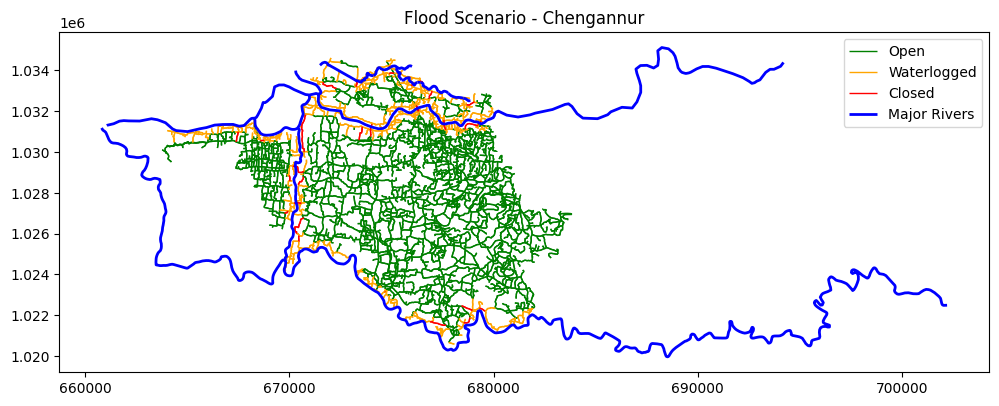

In [36]:
fig, ax = plt.subplots(figsize=(12,12))

colors = {
    "Open":"green",
    "Waterlogged":"orange",
    "Closed":"red"
}

for status, color in colors.items():

    edges_proj[
        edges_proj["status"] == status
    ].plot(
        ax=ax,
        color=color,
        linewidth=1,
        label=status
    )

major_rivers.plot(
    ax=ax,
    color="blue",
    linewidth=2,
    label="Major Rivers"
)

plt.title("Flood Scenario - Chengannur")

plt.legend()

plt.show()

In [37]:
hospital_nodes = infrastructure["hospital"]["nearest_node"].dropna().unique().tolist()

print("Hospitals :", len(hospital_nodes))

Hospitals : 36


In [38]:
before_distance = nx.multi_source_dijkstra_path_length(
    G_before,
    hospital_nodes,
    weight="travel_cost"
)

after_distance = nx.multi_source_dijkstra_path_length(
    G_after,
    hospital_nodes,
    weight="travel_cost"
)

print("Dijkstra completed.")

Dijkstra completed.


In [39]:
accessibility = nodes.copy()

accessibility["before"] = accessibility.index.map(before_distance)

accessibility["after"] = accessibility.index.map(after_distance)

accessibility["increase"] = (
    accessibility["after"]
    -
    accessibility["before"]
)

display(accessibility.head())

,y,x,junction,street_count,highway,geometry,before,after,increase
osmid,,,,,,,,,
280901887,9.336928,76.602490,yes,3,NaN,POINT (76.60249 9.33693),1846.532952,3253.798448,1407.265496
280901888,9.337241,76.602022,NaN,3,NaN,POINT (76.60202 9.33724),1784.529173,3191.794669,1407.265496
280902627,9.331714,76.605670,NaN,3,crossing,POINT (76.60567 9.33171),1497.474679,1497.474679,0.000000
280902633,9.334697,76.604579,NaN,3,NaN,POINT (76.60458 9.3347),1850.456702,3598.018263,1747.561562
280902635,9.335443,76.604187,NaN,4,NaN,POINT (76.60419 9.33544),1944.241936,3504.233029,1559.991094


In [40]:
changed = accessibility[
    accessibility["increase"] > 0
]

print("Nodes affected :", len(changed))

display(
    changed.sort_values(
        "increase",
        ascending=False
    ).head(20)
)

Nodes affected : 1024


,y,x,junction,street_count,highway,geometry,before,after,increase
osmid,,,,,,,,,
5976512562,9.325706,76.552594,NaN,1,NaN,POINT (76.55259 9.32571),966.154494,630493.752075,629527.597582
5142974112,9.325692,76.553430,NaN,3,NaN,POINT (76.55343 9.32569),873.917347,630263.159208,629389.241861
7497557822,9.332039,76.636586,NaN,1,NaN,POINT (76.63659 9.33204),3036.772413,222166.991968,219130.219555
7496742265,9.331488,76.639140,NaN,1,NaN,POINT (76.63914 9.33149),2949.198248,222001.375798,219052.177551
7497551773,9.331746,76.638157,NaN,3,NaN,POINT (76.63816 9.33175),2832.776366,221710.321093,218877.544727
7497557834,9.332040,76.638111,NaN,3,NaN,POINT (76.63811 9.33204),2866.826610,221742.127462,218875.300852
7497551756,9.329040,76.628522,NaN,1,NaN,POINT (76.62852 9.32904),2824.838289,221690.475900,218865.637612
7531513174,9.339934,76.630889,NaN,1,NaN,POINT (76.63089 9.33993),3530.332374,222221.779965,218691.447592
6309184903,9.333269,76.638622,NaN,3,NaN,POINT (76.63862 9.33327),3016.635070,221367.606313,218350.971243


In [41]:
import numpy as np
valid = accessibility.replace([np.inf, -np.inf], np.nan)



print("Average Before")
print(round(valid["before"].mean(),2))

print()

print("Average After")
print(round(valid["after"].mean(),2))

print()

print("Average Increase")
print(round(valid["increase"].mean(),2))

print()

print("Maximum Increase")
print(round(valid["increase"].max(),2))

Average Before
1531.14

Average After
5306.42

Average Increase
3775.28

Maximum Increase
629527.6


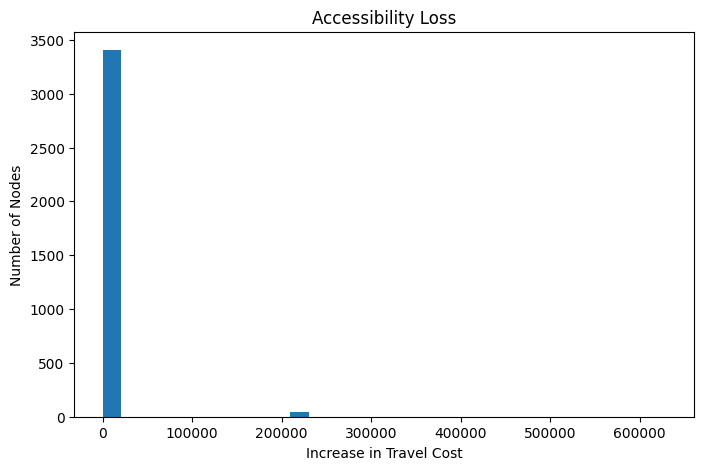

In [42]:
import numpy as np

plt.figure(figsize=(8,5))

increase = accessibility["increase"]

increase = increase.replace([np.inf, -np.inf], np.nan)

increase = increase.dropna()

plt.hist(
    increase,
    bins=30
)

plt.xlabel("Increase in Travel Cost")

plt.ylabel("Number of Nodes")

plt.title("Accessibility Loss")

plt.show()

In [43]:
top20 = accessibility.sort_values(
    "increase",
    ascending=False
)

display(
    top20[
        [
            "before",
            "after",
            "increase"
        ]
    ].head(20)
)

,before,after,increase
osmid,,,
5976512562,966.154494,630493.752075,629527.597582
5142974112,873.917347,630263.159208,629389.241861
7497557822,3036.772413,222166.991968,219130.219555
7496742265,2949.198248,222001.375798,219052.177551
7497551773,2832.776366,221710.321093,218877.544727
7497557834,2866.826610,221742.127462,218875.300852
7497551756,2824.838289,221690.475900,218865.637612
7531513174,3530.332374,222221.779965,218691.447592
6309184903,3016.635070,221367.606313,218350.971243


In [44]:
accessibility["percent_increase"] = (
    accessibility["increase"]
    /
    accessibility["before"]
) * 100

In [45]:
import numpy as np

count = 0

for u, v, k, data in G_after.edges(keys=True, data=True):

    if np.isinf(data["travel_cost"]):
        count += 1

print(count)

0


In [46]:
import numpy as np

print(np.isinf(edges_proj["travel_cost"]).sum())

0


In [47]:
closed_bridges = edges_proj[
    (edges_proj["status"] == "Closed") &
    (edges_proj["bridge"].notna())
].copy()

print("Closed Bridge Segments :", len(closed_bridges))

display(
    closed_bridges[
        ["bridge", "length", "travel_cost"]
    ].head()
)

Closed Bridge Segments : 66


bridge      length    travel_cost
u          v           key                                  
280902633  11483418997 0      yes  279.051025  279051.025202
           11483418996 0      yes  272.142568  272142.568285
307681910  1925312456  0      yes  822.283619  822283.619095
1862573469 1862573521  0      yes  240.257192  240257.192294
1862573521 1862573469  0      yes  240.257192  240257.192294

In [48]:
import copy

results = []

for (u, v, key), row in closed_bridges.iterrows():

    G_temp = copy.deepcopy(G_after)

    if G_temp.has_edge(u, v, key):

        G_temp[u][v][key]["travel_cost"] = (
            G_temp[u][v][key]["length"]
        )

    distance = nx.multi_source_dijkstra_path_length(
        G_temp,
        hospital_nodes,
        weight="travel_cost"
    )

    temp_access = nodes.copy()

    temp_access["distance"] = (
        temp_access.index.map(distance)
    )

    avg = temp_access["distance"].mean()

    improvement = (
        valid["after"].mean() - avg
    )

    results.append({

        "u": u,

        "v": v,

        "length": row["length"],

        "improvement": improvement

    })

print("Simulation Complete.")

Simulation Complete.


In [52]:
restoration = pd.DataFrame(results)

restoration = restoration.sort_values(
    "improvement",
    ascending=False
)

display(restoration.head(20))

,u,v,length,improvement
10,2918316447,2918316428,216.316042,2939.706833
37,5987545608,7513448240,410.879101,2873.327803
19,5142974163,5142974112,629.652497,364.123210
16,5142967710,5142974112,1306.272135,363.462667
6,2403488654,7496723516,119.094360,81.000111
49,7494462533,5987545694,475.269494,75.325272
64,11483418997,280902633,279.051025,53.262032
63,11483418996,280902633,272.142568,52.828758
27,5864236633,5987545372,140.622174,40.660362
5,1925312456,307681910,822.283619,15.128281


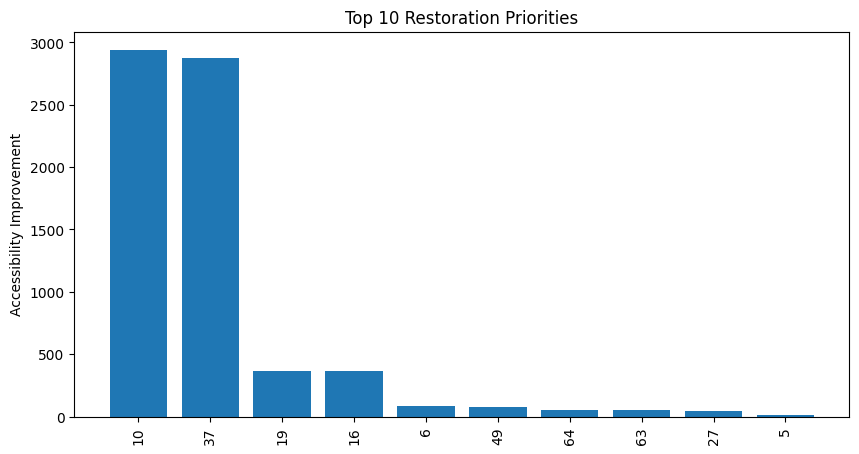

In [53]:
plt.figure(figsize=(10,5))

plt.bar(
    restoration.index[:10].astype(str),
    restoration["improvement"].head(10)
)

plt.xticks(rotation=90)

plt.ylabel("Accessibility Improvement")

plt.title("Top 10 Restoration Priorities")

plt.show()

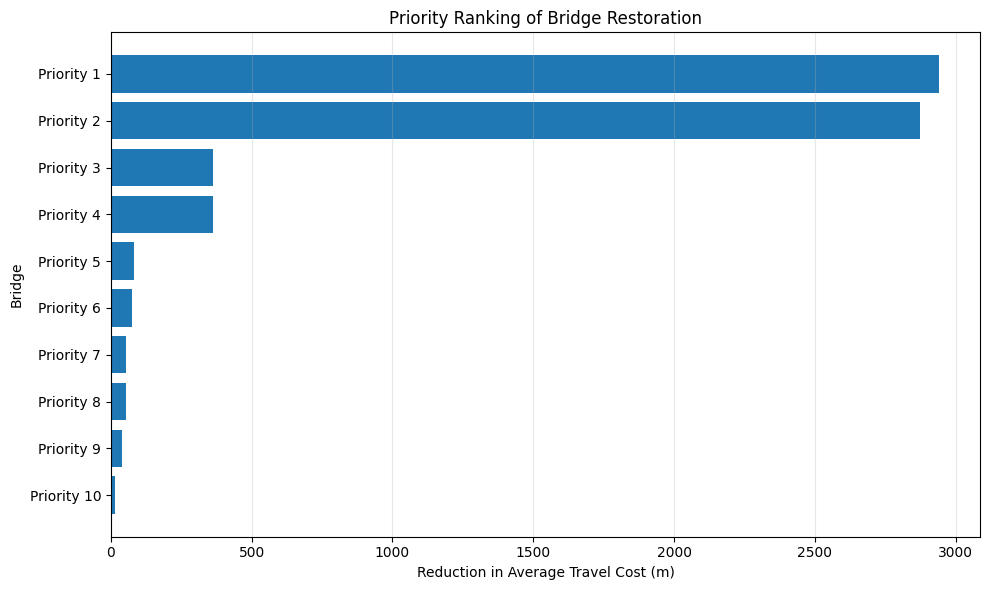

,Priority,u,v,length,improvement
10,Priority 1,2918316447,2918316428,216.316042,2939.706833
37,Priority 2,5987545608,7513448240,410.879101,2873.327803
19,Priority 3,5142974163,5142974112,629.652497,364.123210
16,Priority 4,5142967710,5142974112,1306.272135,363.462667
6,Priority 5,2403488654,7496723516,119.094360,81.000111
49,Priority 6,7494462533,5987545694,475.269494,75.325272
64,Priority 7,11483418997,280902633,279.051025,53.262032
63,Priority 8,11483418996,280902633,272.142568,52.828758
27,Priority 9,5864236633,5987545372,140.622174,40.660362
5,Priority 10,1925312456,307681910,822.283619,15.128281


In [55]:
top10 = restoration.head(10).copy()

# Give readable labels
top10["Priority"] = [
    f"Priority {i+1}" for i in range(len(top10))
]

plt.figure(figsize=(10,6))

plt.barh(
    top10["Priority"],
    top10["improvement"]
)

plt.gca().invert_yaxis()

plt.xlabel("Reduction in Average Travel Cost (m)")
plt.ylabel("Bridge")
plt.title("Priority Ranking of Bridge Restoration")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

display(
    top10[
        [
            "Priority",
            "u",
            "v",
            "length",
            "improvement"
        ]
    ]
)